# Naive Bayes Deep Dive

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. Load the Data
print("Loading Data...")
y_train = np.load('../data/vectors/y_train.npy', allow_pickle=True)
y_val = np.load('../data/vectors/y_val.npy', allow_pickle=True)
y_test = np.load('../data/vectors/y_test.npy', allow_pickle=True)

# Route A: TF-IDF + SVD
X_train_svd = np.load('../data/vectors/svd_train.npy')
X_val_svd = np.load('../data/vectors/svd_val.npy')
X_test_svd = np.load('../data/vectors/svd_test.npy')

# Route B: Dense Embeddings
X_train_embed = np.load('../data/vectors/embed_train.npy')
X_val_embed = np.load('../data/vectors/embed_val.npy')
X_test_embed = np.load('../data/vectors/embed_test.npy')

LABELS = ['agree', 'disagree', 'discuss', 'unrelated']

Loading Data...


In [2]:
# 2. Master Evaluation & Plotting Function
def evaluate_tuned_model(model, X_train, y_train, X_val, y_val, X_test, y_test, title_prefix=""):
    print(f"\n{'='*60}\n{title_prefix} MODEL EVALUATION\n{'='*60}")
    print(f"Best Parameters Found: {model.best_params_}")
    
    # Get Predictions
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    
    # Print Test Classification Report (What the Professor wants to see)
    print("\n--- HOLD-OUT TEST SET CLASSIFICATION REPORT ---")
    print(classification_report(y_test, y_pred_test, labels=LABELS, zero_division=0))
    
    # --- VISUALIZATIONS ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Train vs Val vs Test F1 Score Comparison (To check Overfitting)
    train_f1 = f1_score(y_train, y_pred_train, average=None, labels=LABELS)
    val_f1 = f1_score(y_val, y_pred_val, average=None, labels=LABELS)
    test_f1 = f1_score(y_test, y_pred_test, average=None, labels=LABELS)
    
    df_plot = pd.DataFrame({
        'Stance': LABELS * 3,
        'F1 Score': np.concatenate([train_f1, val_f1, test_f1]),
        'Split': ['Train']*4 + ['Validation']*4 + ['Test']*4
    })
    
    sns.barplot(data=df_plot, x='Stance', y='F1 Score', hue='Split', ax=axes[0], palette='viridis')
    axes[0].set_title(f"{title_prefix} - Overfit Check (F1 Scores)")
    axes[0].set_ylim(0, 1)
    
    # Plot 2: Test Set Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test, labels=LABELS, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS, ax=axes[1])
    axes[1].set_title(f"{title_prefix} - Test Set Confusion Matrix")
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    plt.show()
    
    # Return train/val/test macro F1 to quickly spot underfitting/overfitting
    macro_train = f1_score(y_train, y_pred_train, average='macro')
    macro_val = f1_score(y_val, y_pred_val, average='macro')
    macro_test = f1_score(y_test, y_pred_test, average='macro')
    
    print(f"Macro F1 -> Train: {macro_train:.4f} | Val: {macro_val:.4f} | Test: {macro_test:.4f}")
    if (macro_train - macro_val) > 0.15:
        print("⚠️ WARNING: Model is overfitting to the training data.")
    elif macro_train < 0.60:
        print("⚠️ WARNING: Model might be underfitting (high bias).")

Initiating GridSearchCV for Gaussian Naive Bayes...

[1/2] Tuning Naive Bayes on Route A (TF-IDF + SVD)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Naive Bayes (TF-IDF + SVD) MODEL EVALUATION
Best Parameters Found: {'clf__var_smoothing': 0.0001}

--- HOLD-OUT TEST SET CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       agree       0.40      0.43      0.41      1674
    disagree       0.54      0.50      0.52      1153
     discuss       0.42      0.62      0.50      2006
   unrelated       0.48      0.27      0.35      2250

    accuracy                           0.45      7083
   macro avg       0.46      0.46      0.45      7083
weighted avg       0.46      0.45      0.44      7083



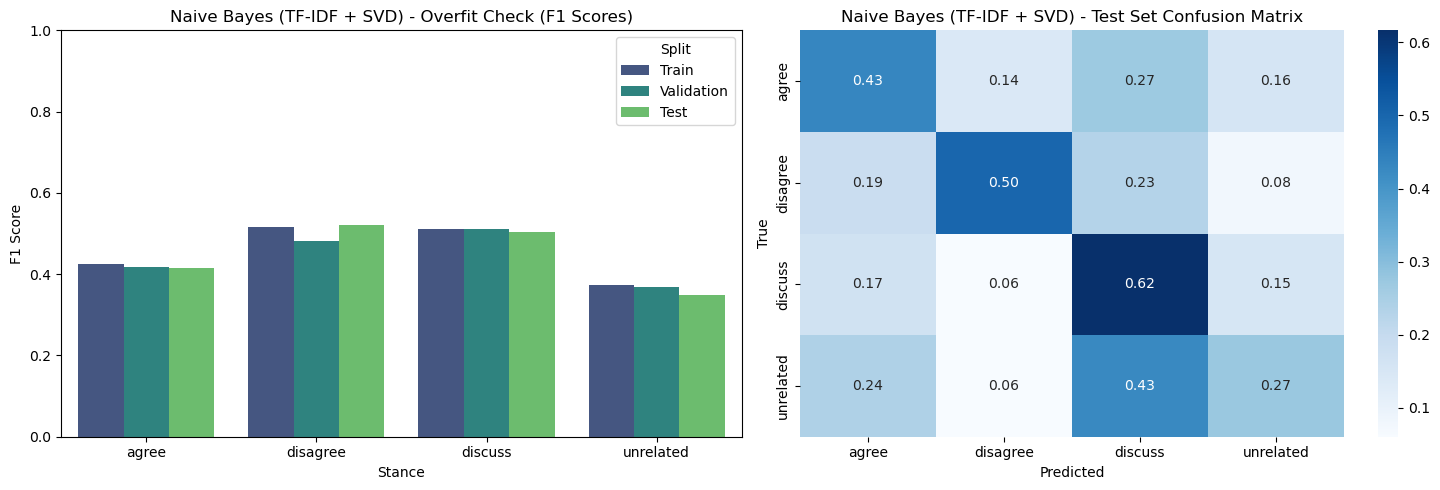

Macro F1 -> Train: 0.4562 | Val: 0.4449 | Test: 0.4464
⚠️ WARNING: Model might be underfitting (high bias).

[2/2] Tuning Naive Bayes on Route B (Dense Embeddings)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Naive Bayes (Embeddings) MODEL EVALUATION
Best Parameters Found: {'clf__var_smoothing': 0.1}

--- HOLD-OUT TEST SET CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       agree       0.49      0.43      0.46      1674
    disagree       0.43      0.61      0.50      1153
     discuss       0.49      0.59      0.53      2006
   unrelated       0.64      0.44      0.52      2250

    accuracy                           0.51      7083
   macro avg       0.51      0.52      0.50      7083
weighted avg       0.53      0.51      0.51      7083



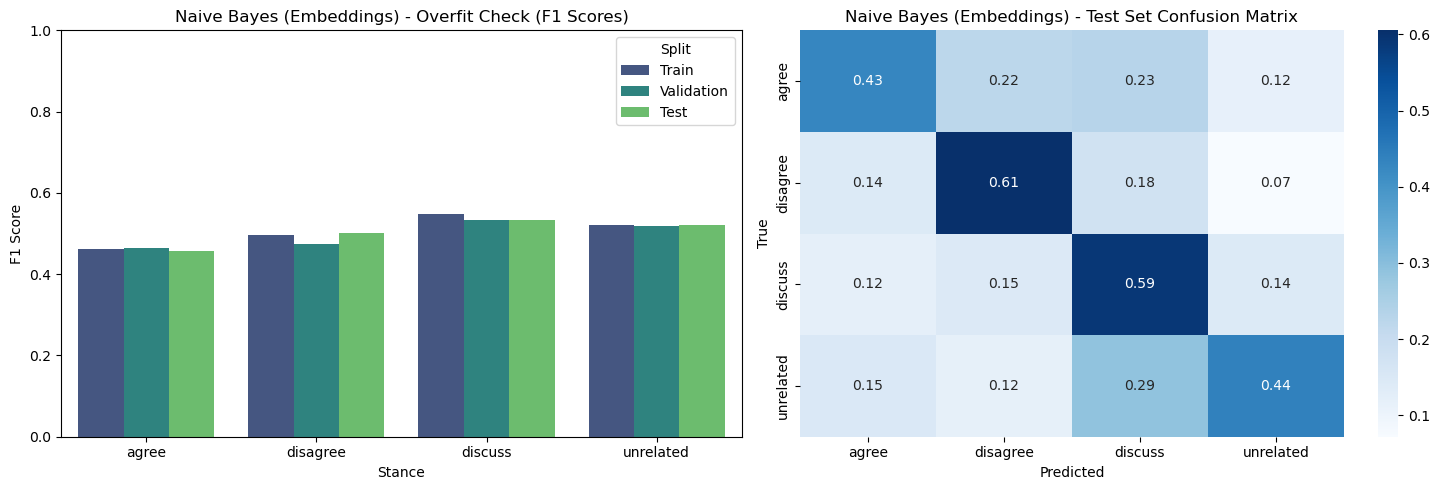

Macro F1 -> Train: 0.5066 | Val: 0.4979 | Test: 0.5029
⚠️ WARNING: Model might be underfitting (high bias).

Saved both tuned Naive Bayes models to '../models/'.


In [3]:
from sklearn.naive_bayes import GaussianNB

# --- GAUSSIAN NAIVE BAYES SETUP ---
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GaussianNB())
])

# Define the Grid for Hyperparameter Tuning
# var_smoothing is the portion of the largest variance of all features that is added to variances for calculation stability
param_grid_nb = {
    'clf__var_smoothing': np.logspace(0, -9, num=10)
}

print("Initiating GridSearchCV for Gaussian Naive Bayes...")

# ==========================================
# ROUTE A: TF-IDF + SVD
# ==========================================
print("\n[1/2] Tuning Naive Bayes on Route A (TF-IDF + SVD)...")
grid_nb_svd = GridSearchCV(nb_pipeline, param_grid_nb, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_nb_svd.fit(X_train_svd, y_train)

# Evaluate
evaluate_tuned_model(grid_nb_svd, X_train_svd, y_train, X_val_svd, y_val, X_test_svd, y_test, title_prefix="Naive Bayes (TF-IDF + SVD)")

# Save Model
joblib.dump(grid_nb_svd.best_estimator_, '../models/NB_best_tfidf_svd.pkl')

# ==========================================
# ROUTE B: DENSE EMBEDDINGS
# ==========================================
print("\n[2/2] Tuning Naive Bayes on Route B (Dense Embeddings)...")
grid_nb_embed = GridSearchCV(nb_pipeline, param_grid_nb, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_nb_embed.fit(X_train_embed, y_train)

# Evaluate
evaluate_tuned_model(grid_nb_embed, X_train_embed, y_train, X_val_embed, y_val, X_test_embed, y_test, title_prefix="Naive Bayes (Embeddings)")

# Save Model
joblib.dump(grid_nb_embed.best_estimator_, '../models/NB_best_embeddings.pkl')

print("\nSaved both tuned Naive Bayes models to '../models/'.")